In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
from pandas import MultiIndex
warnings.filterwarnings('ignore')
import os

In [18]:
os.chdir ("C:\\Academic Projects\\DIABETES-DETECTION\\")
df = pd.read_csv("Diabetes-dataset.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [19]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)

for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

Deepseek

In [47]:
# At the top of your notebook, after imports
df = pd.read_csv("Diabetes-dataset.csv")

# Columns that originally had zeros (treated as missing)
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)

# Impute with median (same as before)
for col in cols_with_zero:
    df[col].fillna(df[col].median(), inplace=True)

# ---- Improved outlier capping ----
def cap_outliers(df, columns, lower_percentile=0.01, upper_percentile=0.99):
    for col in columns:
        lower = df[col].quantile(lower_percentile)
        upper = df[col].quantile(upper_percentile)
        df[col] = df[col].clip(lower, upper)
    return df

cols_to_cap = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 
               'DiabetesPedigreeFunction', 'Age']
df = cap_outliers(df, cols_to_cap)

In [48]:
# Interaction terms (domain knowledge)
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Insulin_Glucose'] = df['Insulin'] * df['Glucose']
df['Age_Pregnancies'] = df['Age'] * df['Pregnancies']   # Pregnancies still exists

# Ratios
df['BMI_Age'] = df['BMI'] / (df['Age'] + 1)   # avoid division by zero
df['DPF_Age'] = df['DiabetesPedigreeFunction'] * df['Age']

In [49]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
feature_names = ['Glucose', 'BMI', 'Age', 'Insulin']
poly_features = poly.fit_transform(df[feature_names])
poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(feature_names))
df = pd.concat([df, poly_df], axis=1)

In [50]:
df.to_csv('Diabetes-dataset_FS_enhanced.csv', index=False)

Identifying the dimensions

In [20]:
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Univarient Analysis

In [21]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: title={'center': 'Outcome'}, ylabel='Frequency'>

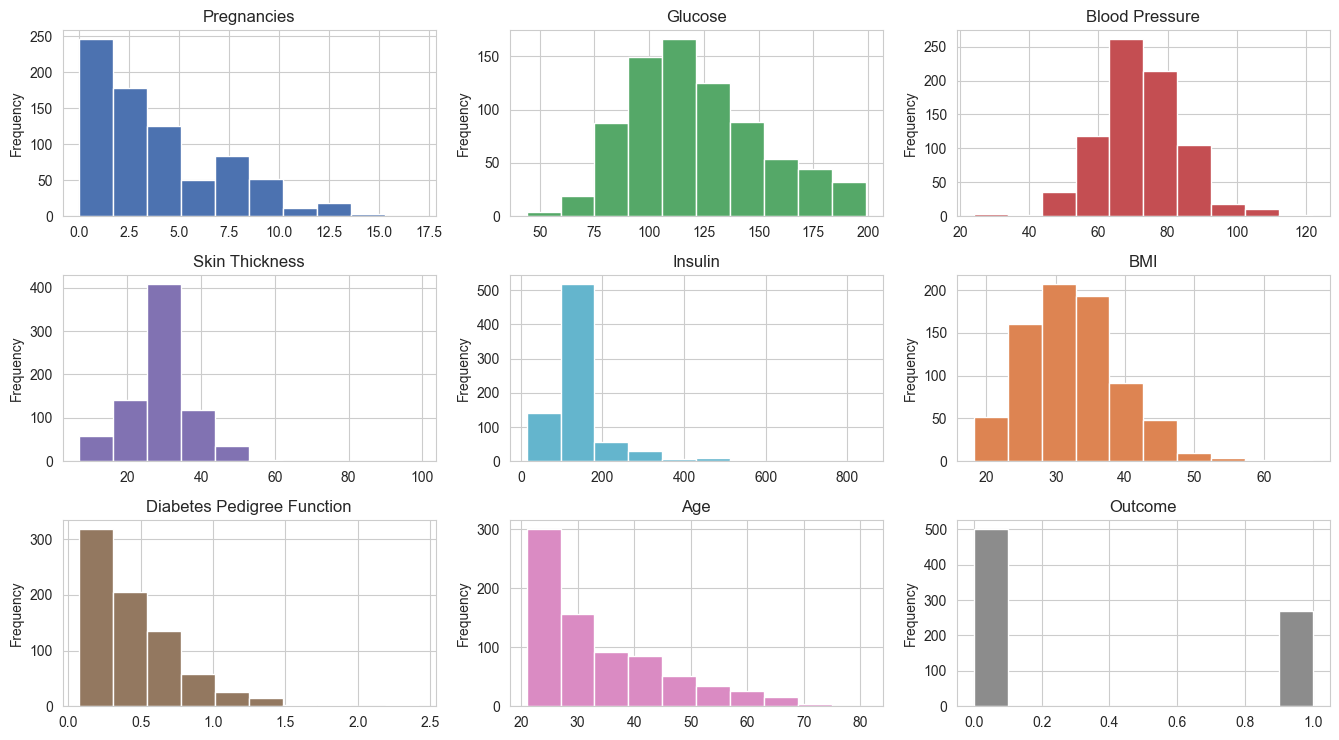

In [22]:
plt.rcParams["figure.figsize"] = [13.5, 7.5]
plt.rcParams["figure.autolayout"] = True

figure, axis = plt.subplots(3, 3)

df['Pregnancies'].plot.hist(title="Pregnancies", ax=axis[0][0], color="#4C72B0")
df['Glucose'].plot.hist(title="Glucose", ax=axis[0][1], color="#55A868")
df['BloodPressure'].plot.hist(title="Blood Pressure", ax=axis[0][2], color="#C44E52")

df['SkinThickness'].plot.hist(title="Skin Thickness", ax=axis[1][0], color="#8172B2")
df['Insulin'].plot.hist(title="Insulin", ax=axis[1][1], color="#64B5CD")
df['BMI'].plot.hist(title="BMI", ax=axis[1][2], color="#DD8452")

df['DiabetesPedigreeFunction'].plot.hist(title="Diabetes Pedigree Function", ax=axis[2][0], color="#937860")
df['Age'].plot.hist(title="Age", ax=axis[2][1], color="#DA8BC3")
df['Outcome'].plot.hist(title="Outcome", ax=axis[2][2], color="#8C8C8C")

In [23]:
sns.set_style("whitegrid")

<Axes: title={'center': 'Outcome'}>

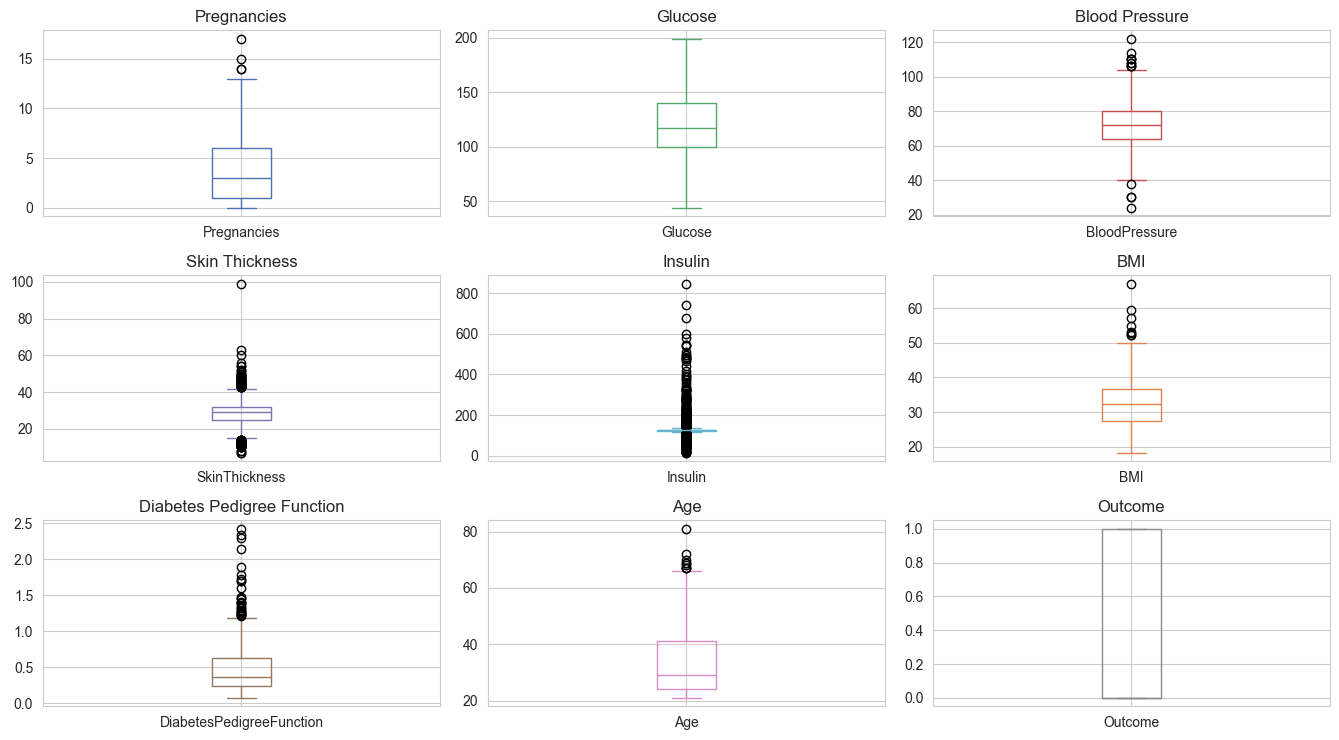

In [24]:
plt.rcParams["figure.figsize"] = [13.5, 7.5]
plt.rcParams["figure.autolayout"] = True

figure, axis = plt.subplots(3, 3)

df['Pregnancies'].plot.box(title="Pregnancies", ax=axis[0][0], color="#4C72B0")
df['Glucose'].plot.box(title="Glucose", ax=axis[0][1], color="#55A868")
df['BloodPressure'].plot.box(title="Blood Pressure", ax=axis[0][2], color="#C44E52")

df['SkinThickness'].plot.box(title="Skin Thickness", ax=axis[1][0], color="#8172B2")
df['Insulin'].plot.box(title="Insulin", ax=axis[1][1], color="#64B5CD")
df['BMI'].plot.box(title="BMI", ax=axis[1][2], color="#DD8452")

df['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function", ax=axis[2][0], color="#937860")
df['Age'].plot.box(title="Age", ax=axis[2][1], color="#DA8BC3")
df['Outcome'].plot.box(title="Outcome", ax=axis[2][2], color="#8C8C8C")

Bivarient Analysis

In [25]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


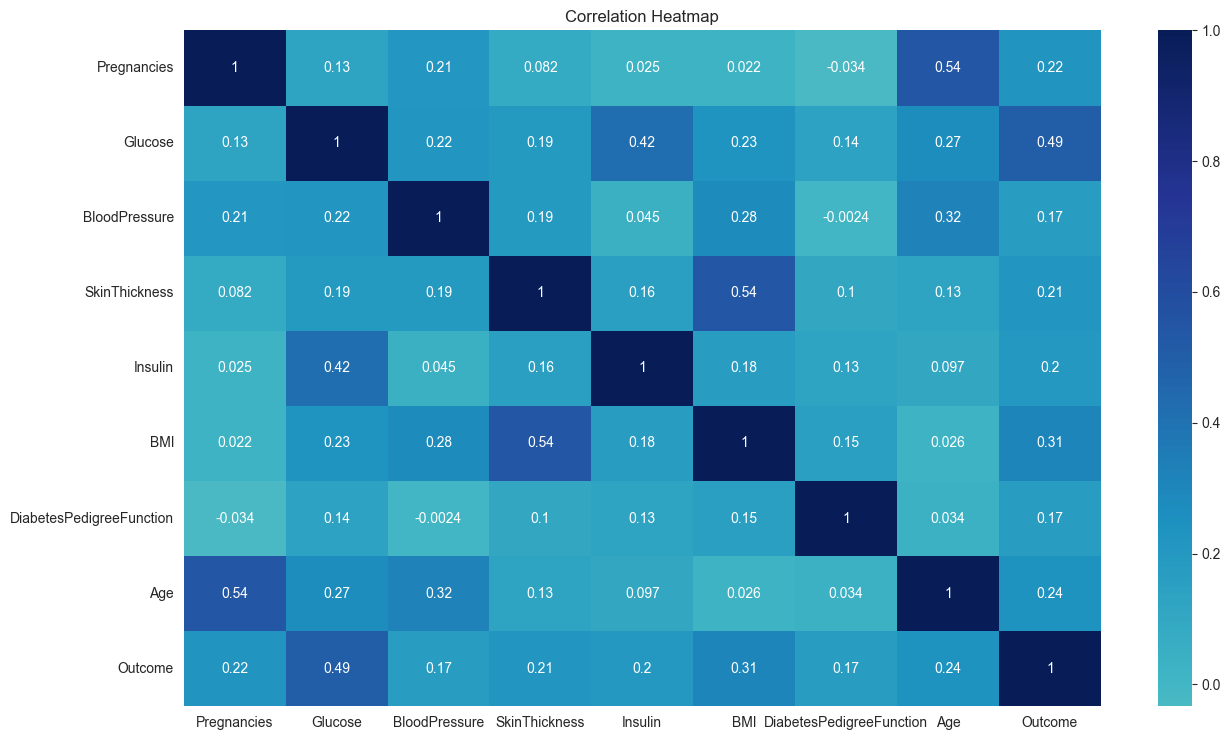

In [26]:
dataplot = sns.heatmap(df.corr(), cmap='YlGnBu', annot=True, center=0)
plt.title("Correlation Heatmap")
plt.show()

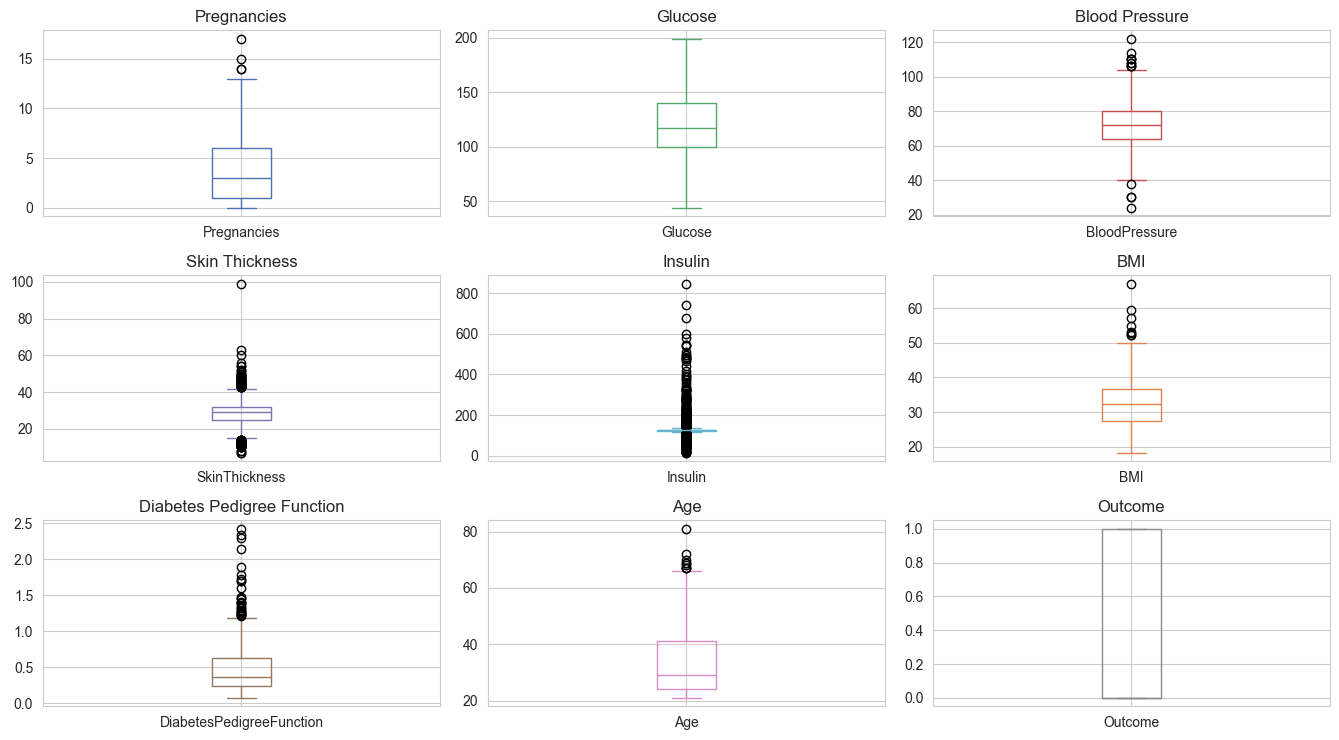

In [27]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = [13.5, 7.5]
plt.rcParams["figure.autolayout"] = True

figure, axis = plt.subplots(3, 3)

df['Pregnancies'].plot.box(title="Pregnancies", ax=axis[0][0], color="#4C72B0")
df['Glucose'].plot.box(title="Glucose", ax=axis[0][1], color="#55A868")
df['BloodPressure'].plot.box(title="Blood Pressure", ax=axis[0][2], color="#C44E52")

df['SkinThickness'].plot.box(title="Skin Thickness", ax=axis[1][0], color="#8172B2")
df['Insulin'].plot.box(title="Insulin", ax=axis[1][1], color="#64B5CD")
df['BMI'].plot.box(title="BMI", ax=axis[1][2], color="#DD8452")

df['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function", ax=axis[2][0], color="#937860")
df['Age'].plot.box(title="Age", ax=axis[2][1], color="#DA8BC3")
df['Outcome'].plot.box(title="Outcome", ax=axis[2][2], color="#8C8C8C")

plt.show()

Checking high related attributes

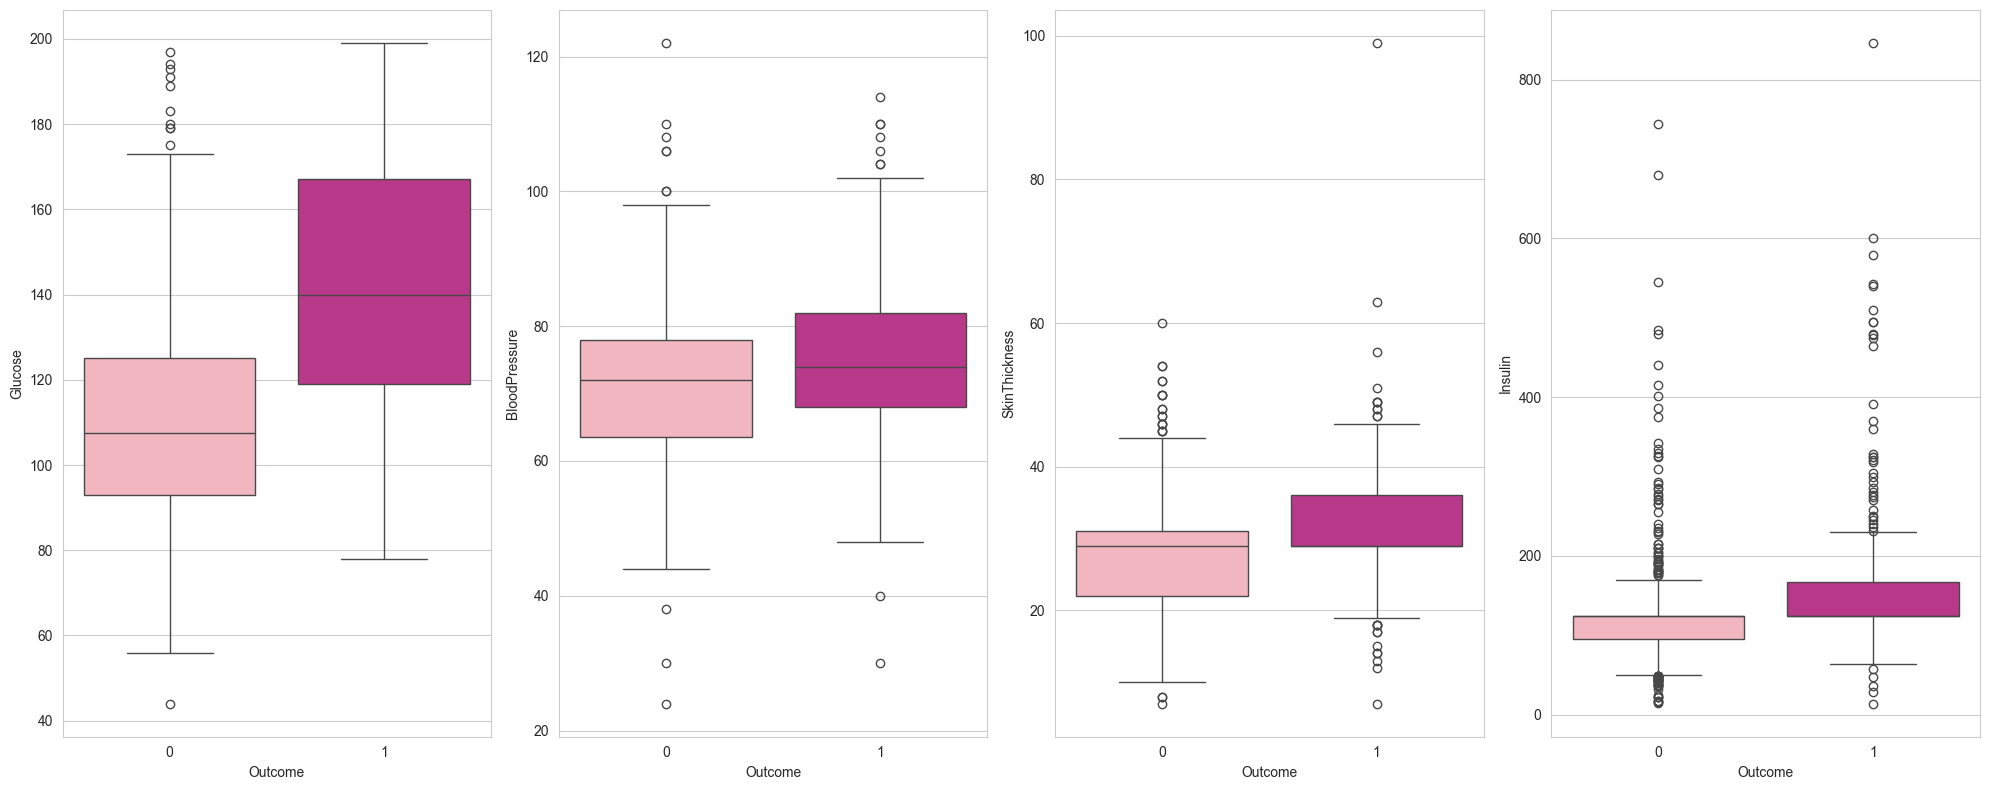

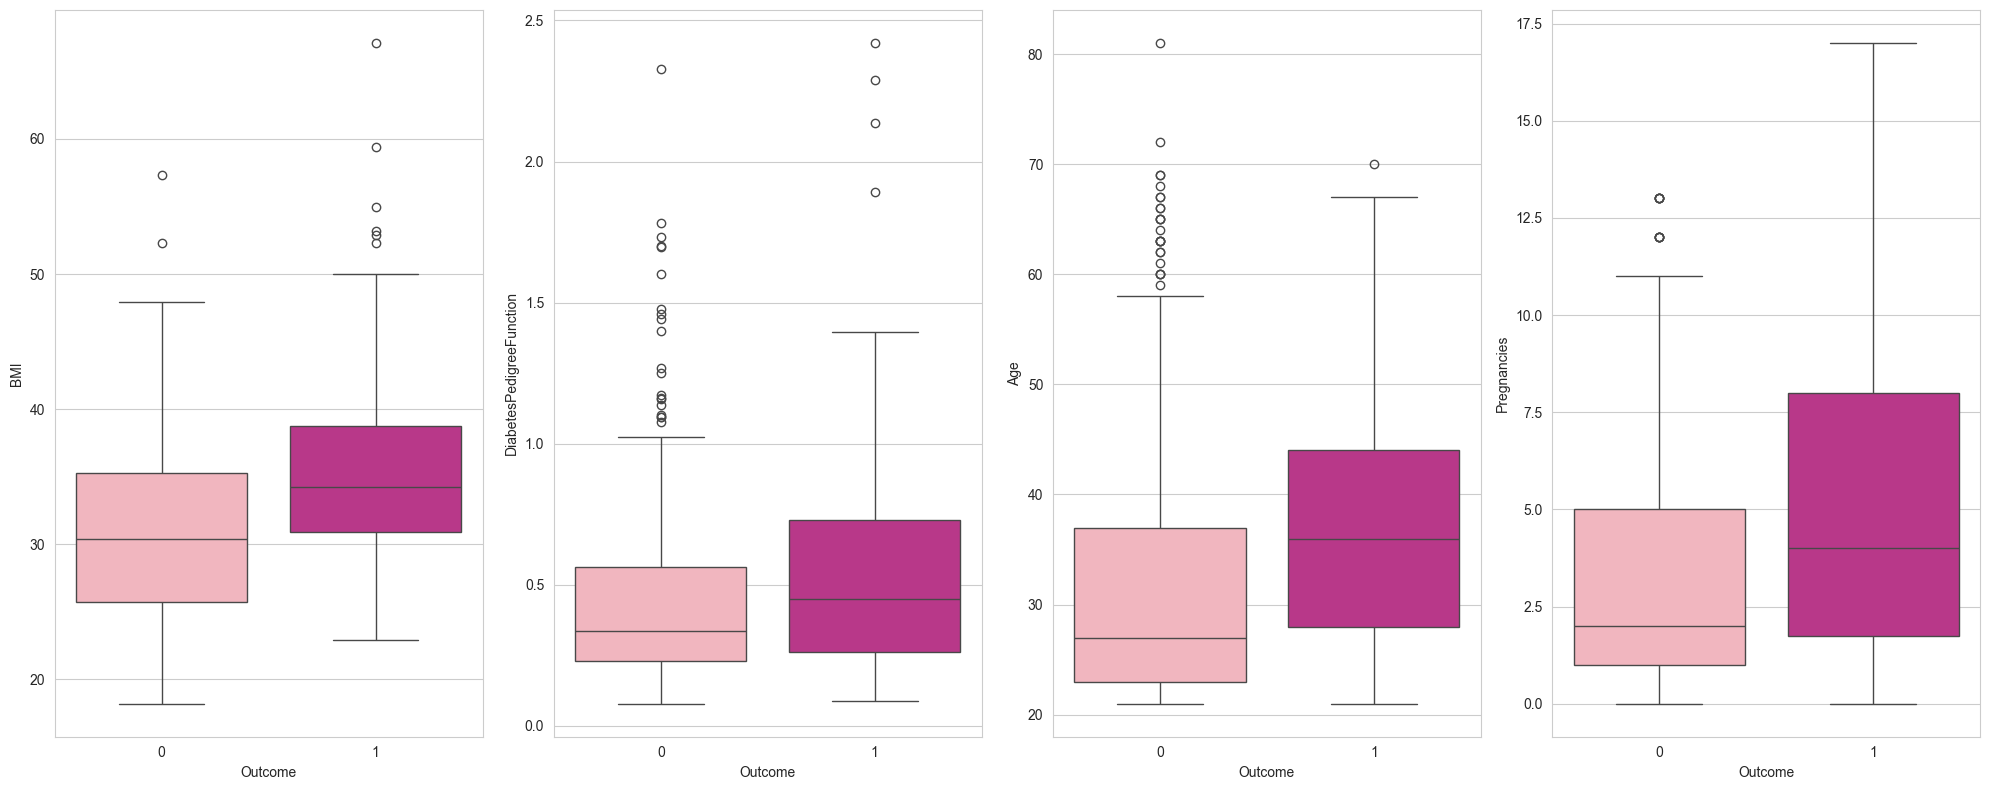

In [28]:
plt.rcParams['figure.figsize'] = (20,8)

f, (ax1,ax2,ax3,ax4) = plt.subplots(1,4)

sns.boxplot(x='Outcome', y='Glucose', data=df, ax=ax1, palette="RdPu")
sns.boxplot(x='Outcome', y='BloodPressure', data=df, ax=ax2, palette="RdPu")
sns.boxplot(x='Outcome', y='SkinThickness', data=df, ax=ax3, palette="RdPu")
sns.boxplot(x='Outcome', y='Insulin', data=df, ax=ax4, palette="RdPu")

f.tight_layout()


f, (ax1,ax2,ax3,ax4) = plt.subplots(1,4)

sns.boxplot(x='Outcome', y='BMI', data=df, ax=ax1, palette="RdPu")
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, ax=ax2, palette="RdPu")
sns.boxplot(x='Outcome', y='Age', data=df, ax=ax3, palette="RdPu")
sns.boxplot(x='Outcome', y='Pregnancies', data=df, ax=ax4, palette="RdPu")

f.tight_layout()

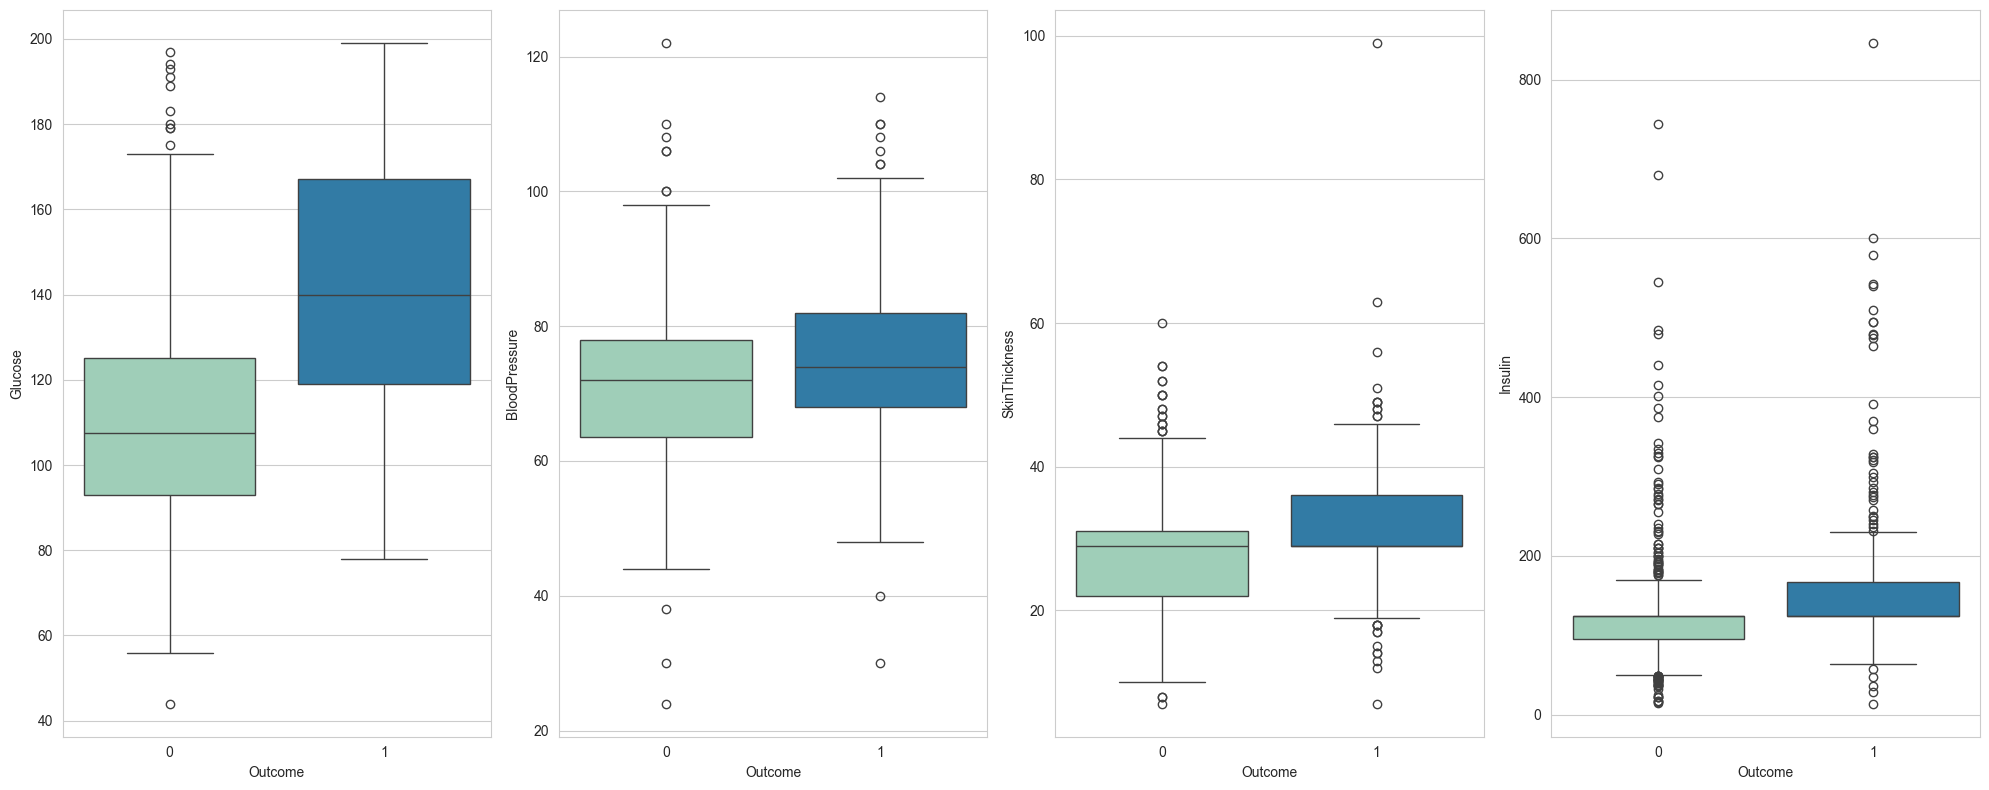

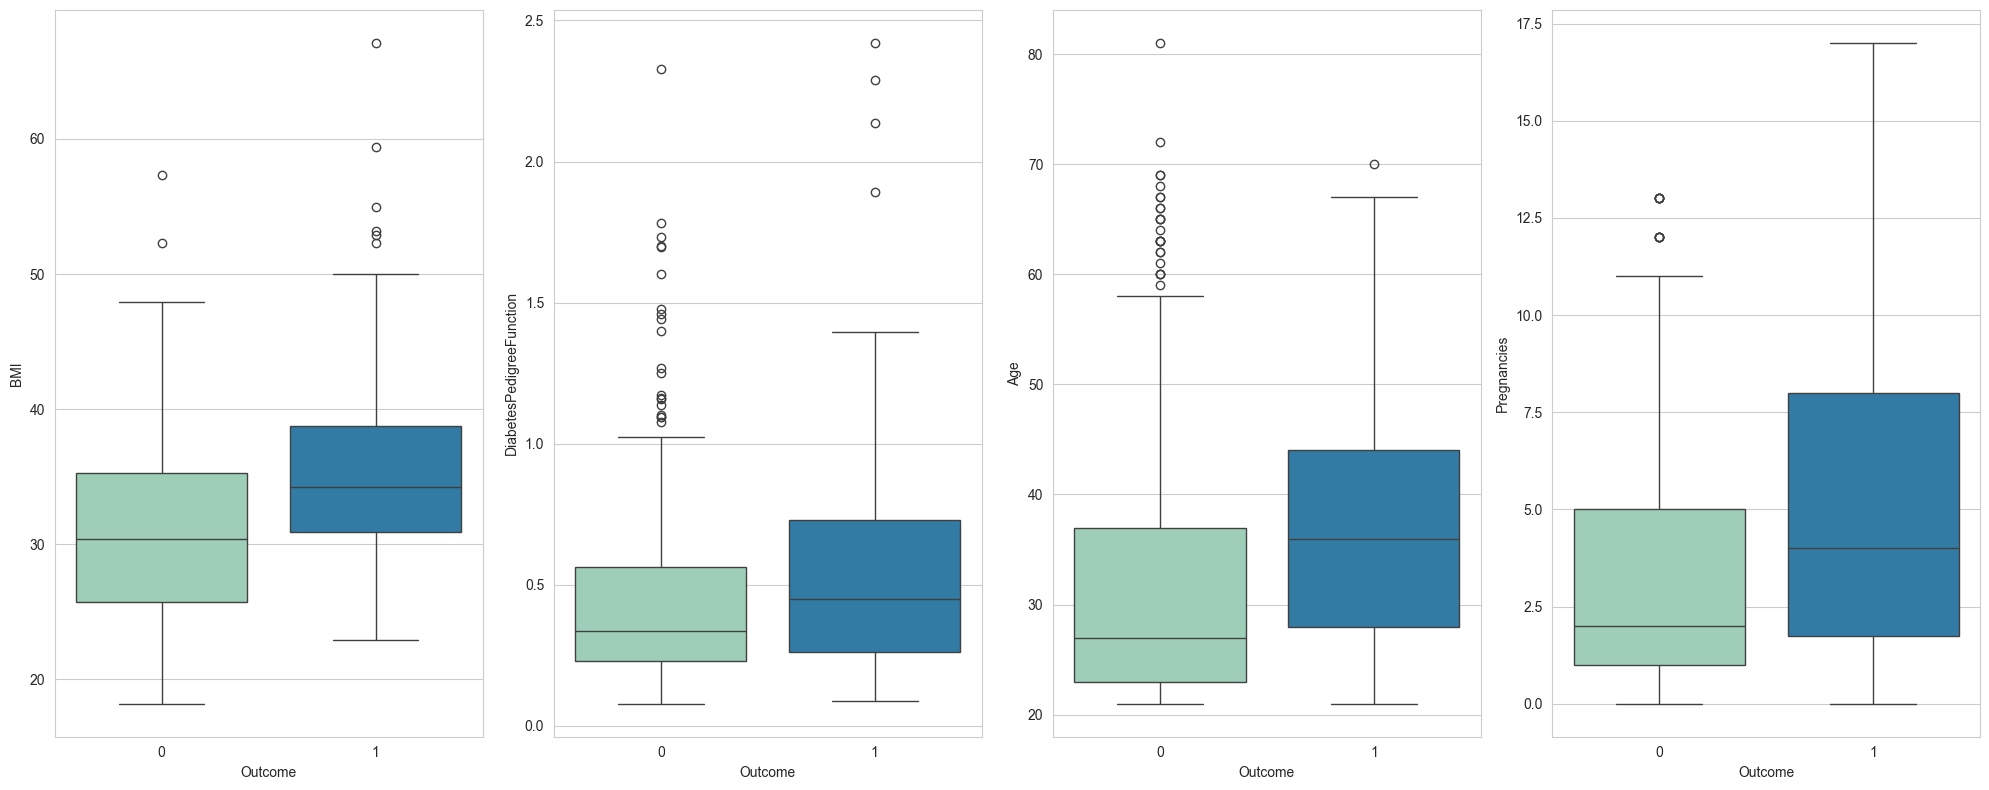

In [29]:
plt.rcParams['figure.figsize'] = (20,8)

f, (ax1,ax2,ax3,ax4) = plt.subplots(1,4)

sns.boxplot(x='Outcome', y='Glucose', data=df, ax=ax1, palette="YlGnBu")
sns.boxplot(x='Outcome', y='BloodPressure', data=df, ax=ax2, palette="YlGnBu")
sns.boxplot(x='Outcome', y='SkinThickness', data=df, ax=ax3, palette="YlGnBu")
sns.boxplot(x='Outcome', y='Insulin', data=df, ax=ax4, palette="YlGnBu")

f.tight_layout()


f, (ax1,ax2,ax3,ax4) = plt.subplots(1,4)

sns.boxplot(x='Outcome', y='BMI', data=df, ax=ax1, palette="YlGnBu")
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, ax=ax2, palette="YlGnBu")
sns.boxplot(x='Outcome', y='Age', data=df, ax=ax3, palette="YlGnBu")
sns.boxplot(x='Outcome', y='Pregnancies', data=df, ax=ax4, palette="YlGnBu")

f.tight_layout()

In [30]:
columns = df.columns

In [31]:
for i in range(len(columns)-1):
    for j in range(i+1,len(columns)):
        if 0.5<=df[columns[i]].corr(df[columns[j]]):
            print("We can drop either "+str(columns[i])+" or "+str(columns[j]))

We can drop either Pregnancies or Age
We can drop either SkinThickness or BMI


In [32]:
columns = columns[1:]
df.drop(['Pregnancies'], axis=1, inplace=True)

In [33]:
df

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,126.0,60.0,29.0,125.0,30.1,0.349,47,1


Mising value treatment

In [34]:
df.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [35]:
df.isnull().sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

there are no missing values in the dataset

outliers treatement

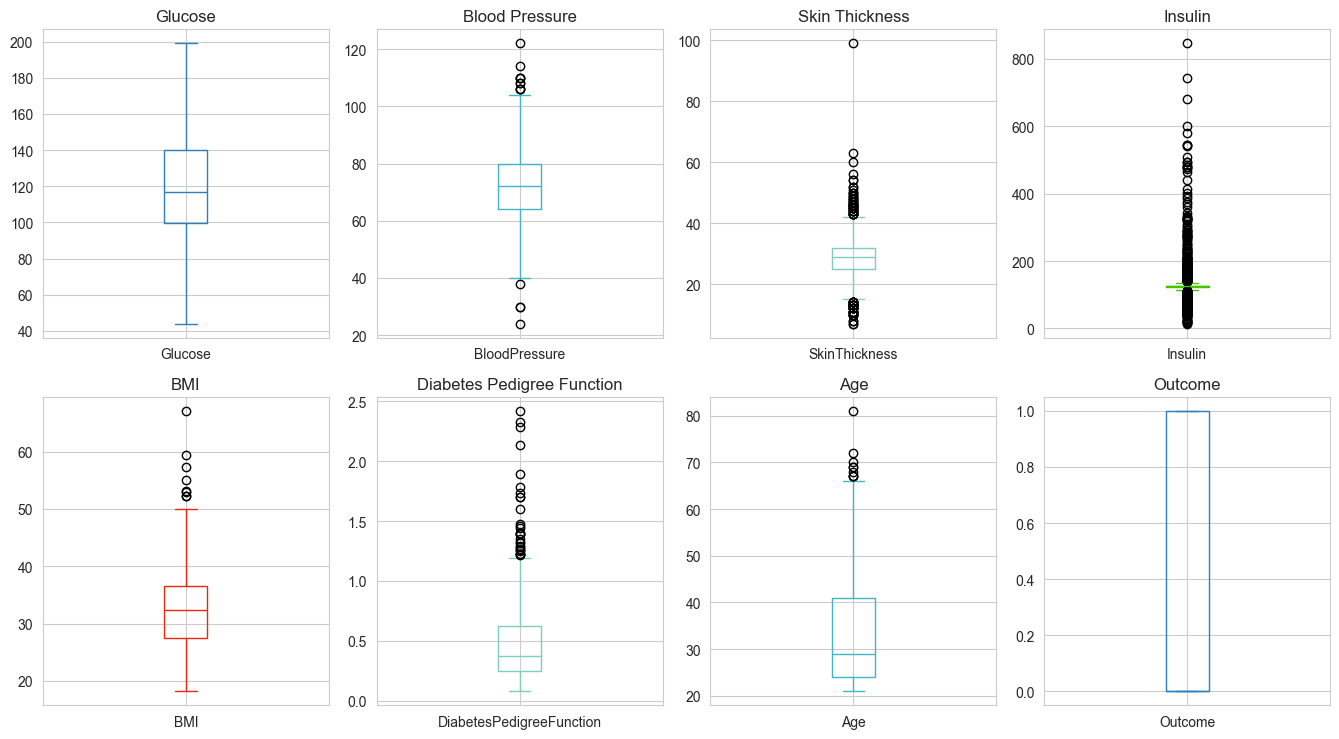

In [36]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = [13.5, 7.5]
plt.rcParams["figure.autolayout"] = True

figure, axis = plt.subplots(2, 4)

df['Glucose'].plot.box(title="Glucose", ax=axis[0][0], color="#2c7fb8")
df['BloodPressure'].plot.box(title="Blood Pressure", ax=axis[0][1], color="#41b6c4")
df['SkinThickness'].plot.box(title="Skin Thickness", ax=axis[0][2], color="#7fcdbb")
df['Insulin'].plot.box(title="Insulin", ax=axis[0][3], color="#47c300")

df['BMI'].plot.box(title="BMI", ax=axis[1][0], color="#e82c0b")
df['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function", ax=axis[1][1], color="#7fcdbb")
df['Age'].plot.box(title="Age", ax=axis[1][2], color="#41b6c4")
df['Outcome'].plot.box(title="Outcome", ax=axis[1][3], color="#2c7fb8")

plt.show()


In [37]:
columns

Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Outliers treatement in Glucose attribute 

In [38]:
Q1 = df.Glucose.quantile(0.25)
Q3 = df.Glucose.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['Glucose']<=lower_limit,'Glucose'] = np.mean(df['Glucose'])
df.loc[df['Glucose']>upper_limit, 'Glucose'] = np.mean(df['Glucose'])

Outliers treatement in BloodPressure attribute 

In [39]:
Q1 = df.BloodPressure.quantile(0.25)
Q3 = df.BloodPressure.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['BloodPressure']<=lower_limit,'BloodPressure'] = np.mean(df['BloodPressure'])
df.loc[df['BloodPressure']>upper_limit,'BloodPressure'] = np.mean(df['BloodPressure'])

Outliers treatement in SkinThickness attribute 

In [40]:
Q1 = df.SkinThickness.quantile(0.25)
Q3 = df.SkinThickness.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['SkinThickness']<=lower_limit,'SkinThickness'] = np.mean(df['SkinThickness'])
df.loc[df['SkinThickness']>upper_limit,'SkinThickness'] = np.mean(df['SkinThickness'])

Outliers treatement in Insulin attribute

In [41]:
Q1 = df.Insulin.quantile(0.25)
Q3 = df.Insulin.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['Insulin']<=lower_limit,'Insulin'] = np.mean(df['Insulin'])
df.loc[df['Insulin']>upper_limit,'Insulin'] = np.mean(df['Insulin'])

Outliers treatement in BMI attribute

In [42]:
Q1 = df.BMI.quantile(0.25)
Q3 = df.BMI.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['BMI']<=lower_limit,'BMI'] = np.mean(df['BMI'])
df.loc[df['BMI']>upper_limit,'BMI'] = np.mean(df['BMI'])

Outliers treatement in DiabtesPedigreeFunction attribute

In [43]:
Q1 = df.DiabetesPedigreeFunction.quantile(0.25)
Q3 = df.DiabetesPedigreeFunction.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['DiabetesPedigreeFunction']<=lower_limit,'DiabetesPedigreeFunction'] = np.mean(df['DiabetesPedigreeFunction'])
df.loc[df['DiabetesPedigreeFunction']>upper_limit,'DiabetesPedigreeFunction'] = np.mean(df['DiabetesPedigreeFunction'])

Outliers treatement in Age attribute

In [44]:
Q1 = df.Age.quantile(0.25)
Q3 = df.Age.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df.loc[df['Age']<=lower_limit,'Age'] = np.mean(df['Age'])
df.loc[df['Age']>upper_limit,'Age'] = np.mean(df['Age'])

Outliers treatement in Outcome attribute

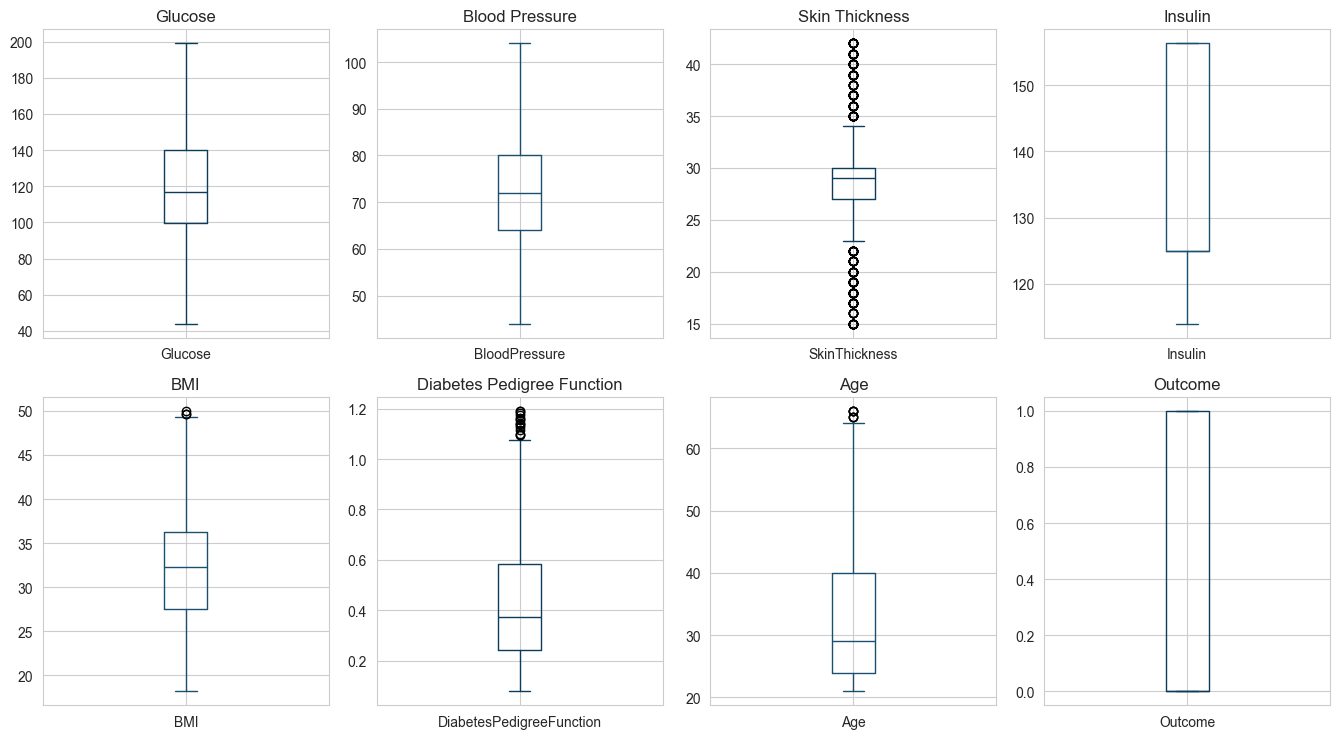

In [45]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = [13.5, 7.5]
plt.rcParams["figure.autolayout"] = True

figure, axis = plt.subplots(2, 4)

df['Glucose'].plot.box(title="Glucose", ax=axis[0][0], color="#0B3C5D")
df['BloodPressure'].plot.box(title="Blood Pressure", ax=axis[0][1], color="#1B4F72")
df['SkinThickness'].plot.box(title="Skin Thickness", ax=axis[0][2], color="#0B3C5D")
df['Insulin'].plot.box(title="Insulin", ax=axis[0][3], color="#1B4F72")

df['BMI'].plot.box(title="BMI", ax=axis[1][0], color="#1B4F72")
df['DiabetesPedigreeFunction'].plot.box(title="Diabetes Pedigree Function", ax=axis[1][1], color="#0B3C5D")
df['Age'].plot.box(title="Age", ax=axis[1][2], color="#1B4F72")
df['Outcome'].plot.box(title="Outcome", ax=axis[1][3], color="#0B3C5D")

plt.show()

Exporting Preproceesing Dataset

In [46]:
df.to_csv('Diabetes-dataset_FS.csv', encoding='utf-8', index=False)